In [2]:
import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import umap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (12, 6), "font.size": 11})

DATA_PATH  = "../data/processed/processed_data.csv"
TFIDF_PATH = "../models/tfidf_vectorizer.pkl"
EMB_PATH   = "../data/processed/embeddings.npy"
OUT_DATA   = "../data/processed/clustered_data.csv"
OUT_KM     = "../models/kmeans_k3.pkl"
OUT_UMAP   = "../models/umap_reducer.pkl"
OUT_FIG    = "../outputs/figures"

for d in [OUT_FIG, "../models"]:
    os.makedirs(d, exist_ok=True)

print("Setup complete")

Setup complete


In [3]:
df = pd.read_csv(DATA_PATH)
print(f"Loaded: {df.shape[0]:,} rows")

encoder = SentenceTransformer("all-MiniLM-L6-v2")

print(f"Encoding {len(df):,} texts ...")
embeddings = encoder.encode(
    df["text_processed"].tolist(),
    show_progress_bar=True,
    batch_size=256,
    normalize_embeddings=True,
)

np.save(EMB_PATH, embeddings)
print(f"Embeddings: {embeddings.shape}  |  saved to {EMB_PATH}")

Loaded: 19,997 rows


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6415.98it/s]


Encoding 19,997 texts ...


Batches: 100%|██████████| 79/79 [03:58<00:00,  3.02s/it]

Embeddings: (19997, 384)  |  saved to ../data/processed/embeddings.npy


  k=3  sil=0.0463  inertia=10,764
  k=4  sil=0.0347  inertia=10,537
  k=5  sil=0.0353  inertia=10,330
  k=6  sil=0.0406  inertia=10,147
  k=7  sil=0.0370  inertia=10,003
  k=8  sil=0.0408  inertia=9,883
  k=9  sil=0.0431  inertia=9,784
  k=10  sil=0.0427  inertia=9,702

Best k = 3  (silhouette = 0.0463)


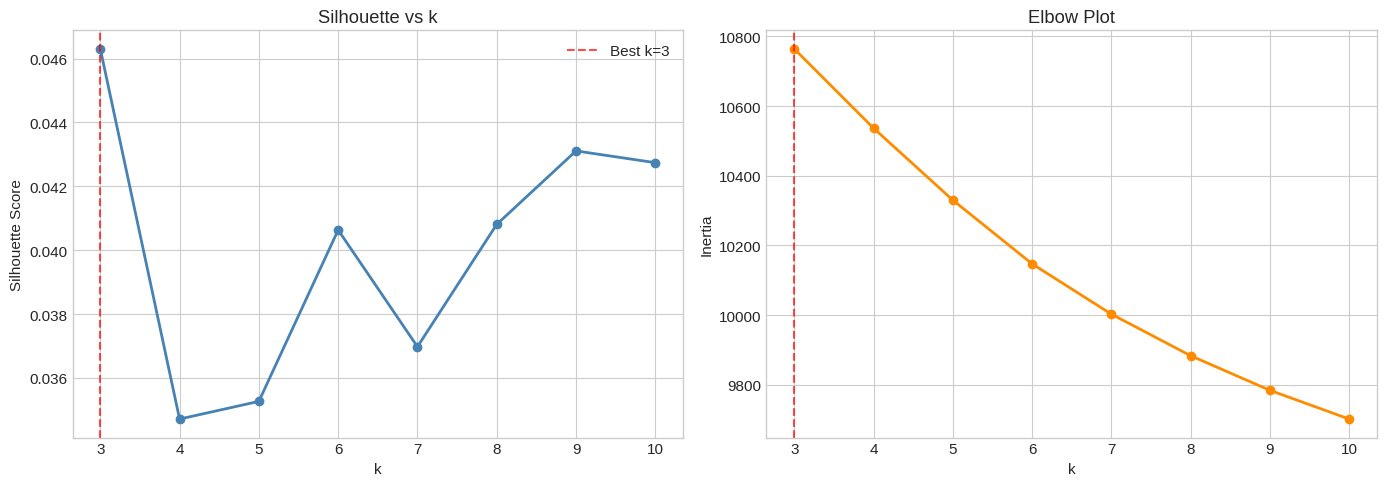

In [4]:
K_RANGE = range(3, 11)
sil_scores = []
inertias   = []

for k in K_RANGE:
    km = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        max_iter=300,
        random_state=RANDOM_STATE,
    )
    labels = km.fit_predict(embeddings)
    sil = silhouette_score(embeddings, labels, sample_size=5_000, random_state=RANDOM_STATE)

    sil_scores.append(sil)
    inertias.append(km.inertia_)
    print(f"  k={k}  sil={sil:.4f}  inertia={km.inertia_:,.0f}")

BEST_K = list(K_RANGE)[int(np.argmax(sil_scores))]
print(f"\nBest k = {BEST_K}  (silhouette = {max(sil_scores):.4f})")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(list(K_RANGE), sil_scores, "o-", color="steelblue", lw=2)
ax1.axvline(BEST_K, color="red", ls="--", alpha=0.7, label=f"Best k={BEST_K}")
ax1.set(xlabel="k", ylabel="Silhouette Score", title="Silhouette vs k")
ax1.legend()
ax1.set_xticks(list(K_RANGE))

ax2.plot(list(K_RANGE), inertias, "o-", color="darkorange", lw=2)
ax2.axvline(BEST_K, color="red", ls="--", alpha=0.7)
ax2.set(xlabel="k", ylabel="Inertia", title="Elbow Plot")
ax2.set_xticks(list(K_RANGE))

plt.tight_layout()
plt.savefig(f"{OUT_FIG}/04_k_selection.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
FINAL_K = 3

km_final = KMeans(
    n_clusters=FINAL_K,
    init="k-means++",
    n_init=20,
    max_iter=500,
    random_state=RANDOM_STATE,
)
df["cluster"] = km_final.fit_predict(embeddings)

joblib.dump(km_final, OUT_KM)
print(f"Final KMeans (k={FINAL_K}) saved to {OUT_KM}")

sil_final = silhouette_score(
    embeddings, df["cluster"],
    sample_size=5_000, random_state=RANDOM_STATE,
)
print(f"  Silhouette score: {sil_final:.4f}\n")

print(f"{'Cluster':<10}  {'Count':>7}  {'%':>6}")
print("-" * 27)
for c in range(FINAL_K):
    n = (df["cluster"] == c).sum()
    print(f"  {c:<8}  {n:>7,}  {n/len(df)*100:>5.1f}%")

Final KMeans (k=3) saved to ../models/kmeans_k3.pkl
  Silhouette score: 0.0463

Cluster       Count       %
---------------------------
  0           8,672   43.4%
  1           3,668   18.3%
  2           7,657   38.3%


In [7]:
tfidf = joblib.load(TFIDF_PATH)
feature_names = np.array(tfidf.get_feature_names_out())
tfidf_matrix  = tfidf.transform(df["text_processed"])

cluster_keywords = {}

for c in range(FINAL_K):
    mask = (df["cluster"] == c).values
    cluster_mean = tfidf_matrix[mask].mean(axis=0).A1
    top_idx = cluster_mean.argsort()[::-1][:10]

    keywords = feature_names[top_idx].tolist()
    scores   = cluster_mean[top_idx].tolist()
    cluster_keywords[c] = keywords

    print(f"Cluster {c}  (n={mask.sum():,})")
    for kw, sc in zip(keywords, scores):
        print(f"    {sc:.4f}  {kw}")
    print()

Cluster 0  (n=8,672)
    0.0560  report
    0.0490  credit
    0.0392  credit report
    0.0350  information
    0.0314  reporting
    0.0250  section
    0.0240  remove
    0.0238  inaccurate
    0.0218  item
    0.0210  right

Cluster 1  (n=3,668)
    0.0844  debt
    0.0459  collection
    0.0289  owe
    0.0288  credit
    0.0271  report
    0.0232  call
    0.0228  letter
    0.0225  send
    0.0220  collect
    0.0219  receive

Cluster 2  (n=7,657)
    0.0306  card
    0.0295  call
    0.0294  payment
    0.0240  pay
    0.0226  charge
    0.0220  tell
    0.0207  time
    0.0205  receive
    0.0204  make
    0.0195  say



In [8]:
print("Cluster x Product distribution:\n")
ct_product     = pd.crosstab(df["cluster"], df["product"])
ct_product_pct = ct_product.div(ct_product.sum(axis=1), axis=0).mul(100).round(1)

for c in range(FINAL_K):
    print(f"  Cluster {c}")
    for prod in ct_product.columns:
        cnt = ct_product.loc[c, prod]
        pct = ct_product_pct.loc[c, prod]
        print(f"    {prod:<25s}  {cnt:>5,}  ({pct:>5.1f}%)")
    print()

CLUSTER_LABELS = {
    0: f"C0 - {', '.join(cluster_keywords[0][:3])}",
    1: f"C1 - {', '.join(cluster_keywords[1][:3])}",
    2: f"C2 - {', '.join(cluster_keywords[2][:3])}",
}

df["cluster_label"] = df["cluster"].map(CLUSTER_LABELS)

print("Assigned cluster labels:")
for k, v in CLUSTER_LABELS.items():
    print(f"  {k}: {v}")

Cluster x Product distribution:

  Cluster 0
    Bank Account                  70  (  0.8%)
    Credit Card                  328  (  3.8%)
    Credit Reporting           6,676  ( 77.0%)
    Debt collection            1,562  ( 18.0%)
    Mortgage                      36  (  0.4%)

  Cluster 1
    Bank Account                  13  (  0.4%)
    Credit Card                   72  (  2.0%)
    Credit Reporting             524  ( 14.3%)
    Debt collection            2,966  ( 80.9%)
    Mortgage                      93  (  2.5%)

  Cluster 2
    Bank Account               2,199  ( 28.7%)
    Credit Card                2,349  ( 30.7%)
    Credit Reporting             797  ( 10.4%)
    Debt collection              953  ( 12.4%)
    Mortgage                   1,359  ( 17.7%)

Assigned cluster labels:
  0: C0 - report, credit, credit report
  1: C1 - debt, collection, owe
  2: C2 - card, call, payment


Computing UMAP projection ...
UMAP fitted and saved to ../models/umap_reducer.pkl


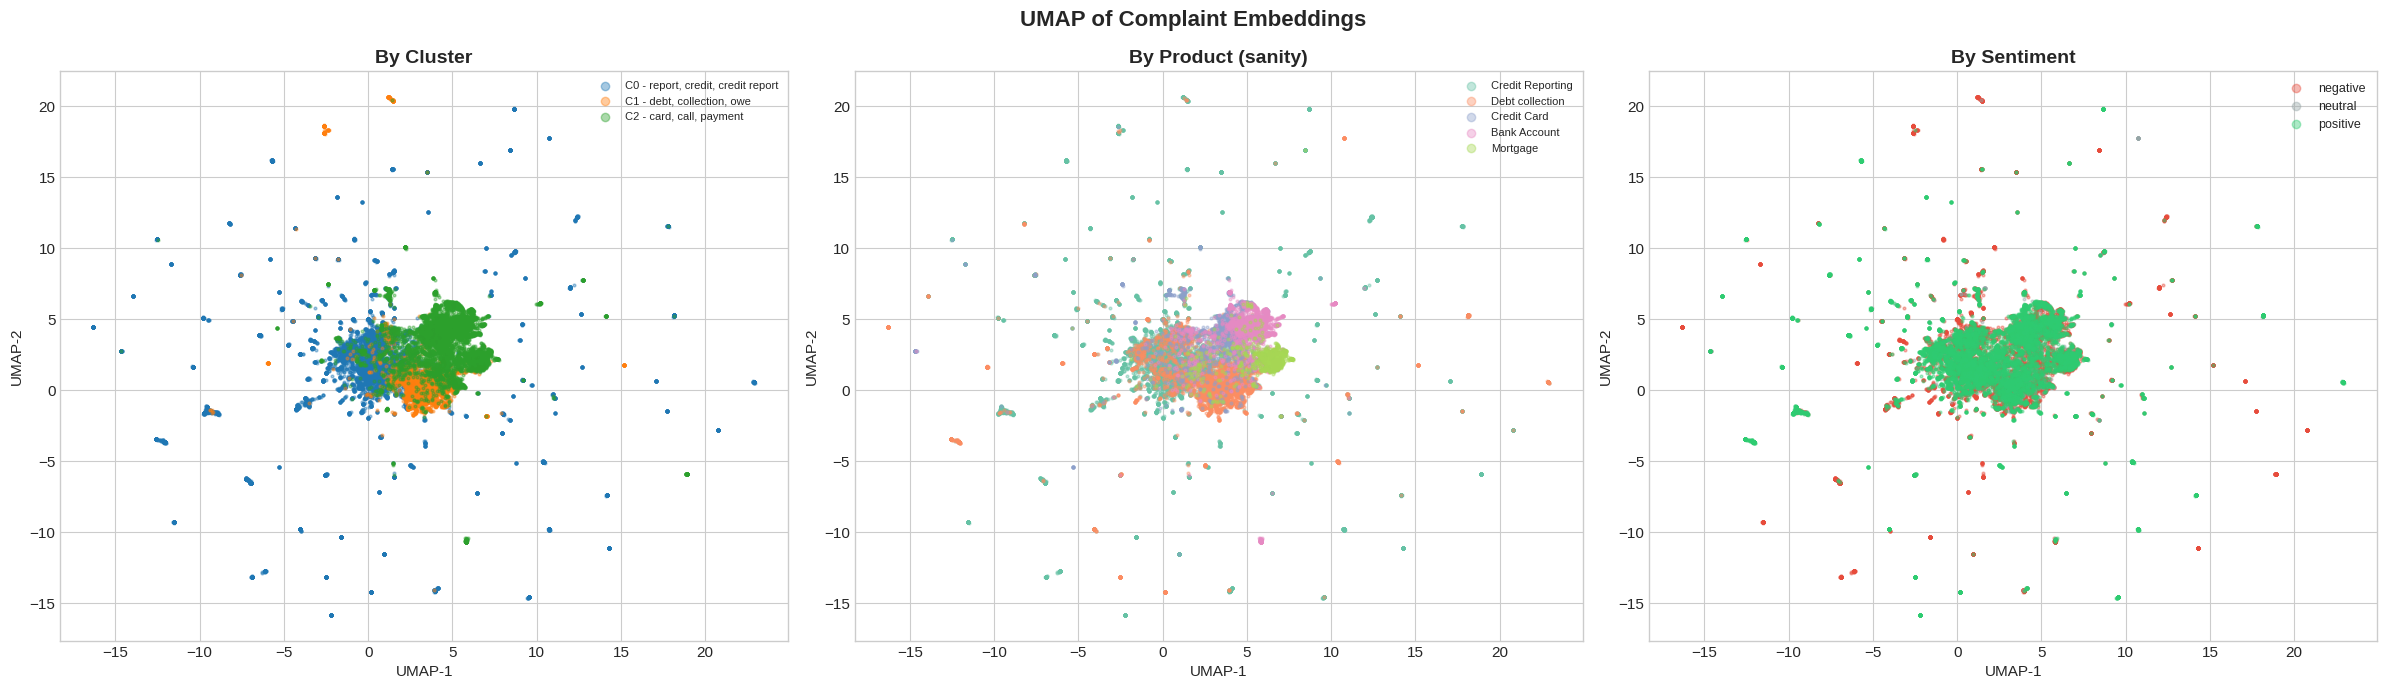

In [9]:
print("Computing UMAP projection ...")
reducer = umap.UMAP(
    n_components=2,
    random_state=RANDOM_STATE,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
)
umap_2d = reducer.fit_transform(embeddings)
df["umap_x"], df["umap_y"] = umap_2d[:, 0], umap_2d[:, 1]

joblib.dump(reducer, OUT_UMAP)
print(f"UMAP fitted and saved to {OUT_UMAP}")

fig, axes = plt.subplots(1, 3, figsize=(24, 7))
scatter_kw = dict(s=4, alpha=0.4)

cluster_pal = sns.color_palette("tab10", FINAL_K)
for c in range(FINAL_K):
    m = df["cluster"] == c
    axes[0].scatter(
        df.loc[m, "umap_x"], df.loc[m, "umap_y"],
        color=cluster_pal[c], label=CLUSTER_LABELS[c], **scatter_kw,
    )
axes[0].set_title("By Cluster", fontsize=14, fontweight="bold")
axes[0].legend(fontsize=8, markerscale=3)

prod_pal = sns.color_palette("Set2", df["product"].nunique())
for i, prod in enumerate(df["product"].value_counts().index):
    m = df["product"] == prod
    axes[1].scatter(
        df.loc[m, "umap_x"], df.loc[m, "umap_y"],
        color=prod_pal[i], label=prod, **scatter_kw,
    )
axes[1].set_title("By Product (sanity)", fontsize=14, fontweight="bold")
axes[1].legend(fontsize=8, markerscale=3)

sent_colors = {"negative": "#e74c3c", "neutral": "#95a5a6", "positive": "#2ecc71"}
for sent, color in sent_colors.items():
    m = df["sentiment"] == sent
    axes[2].scatter(
        df.loc[m, "umap_x"], df.loc[m, "umap_y"],
        color=color, label=sent, **scatter_kw,
    )
axes[2].set_title("By Sentiment", fontsize=14, fontweight="bold")
axes[2].legend(fontsize=9, markerscale=3)

for ax in axes:
    ax.set(xlabel="UMAP-1", ylabel="UMAP-2")

plt.suptitle("UMAP of Complaint Embeddings", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUT_FIG}/04_umap_visualization.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
KEEP_COLS = [
    "narrative", "product", "product_raw", "issue", "company_response",
    "word_count", "text_clean", "text_processed",
    "compound", "sentiment",
    "cluster", "cluster_label",
    "umap_x", "umap_y",
]

df[KEEP_COLS].to_csv(OUT_DATA, index=False)

print(f"Saved: {OUT_DATA}  ({len(df):,} rows x {len(KEEP_COLS)} columns)")
print(f"  File size: {os.path.getsize(OUT_DATA) / 1e6:.1f} MB")

Saved: ../data/processed/clustered_data.csv  (19,997 rows x 14 columns)
  File size: 37.5 MB
